In [30]:
#unified_df.to_csv(r'F:\zizo\RTKCorrection\src\research\data\training\dataBDS2.csv', index=False)
import pandas as pd
unified_df = pd.read_csv(r'F:\zizo\RTKCorrection\src\research\data\training\dataBDS2.csv')
unified_df.columns

Index(['Unnamed: 0.1', 'GPST', 'avg_snr', 'min_snr', 'max_residual', 'x_x',
       'y_x', 'z_x', 'ns', 'sdx(m)', 'sdy(m)', 'sdz(m)', 'sdxy(m)', 'sdyz(m)',
       'sdzx(m)', 'x_y', 'y_y', 'z_y', 'diff_x', 'diff_y', 'diff_z'],
      dtype='object')

In [31]:
len(unified_df)

147900

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

def train_ensemble_and_evaluate(X_train, X_test, y_train, y_test, feature_cols):

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)
    y_train_scaled = y_scaler.fit_transform(y_train)

    # --- Fixed Random Forest (BEST PARAMS) ---
    print(f"\n{'='*80}\nTRAINING RANDOM FOREST (FIXED HYPERPARAMETERS)\n{'='*80}")

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_scaled, y_train_scaled)

    # --- Make predictions ---
    y_pred_scaled = rf.predict(X_test_scaled)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)
    y_test_vals = y_test.to_numpy()

    # --- Evaluation ---
    print("\n" + "="*80 + "\nFINAL EVALUATION: RANDOM FOREST\n" + "="*80)
    per_axis_rmse = []

    for i, axis in enumerate(['X', 'Y', 'Z']):
        rmse = np.sqrt(mean_squared_error(y_test_vals[:, i], y_pred[:, i]))
        per_axis_rmse.append(rmse)
        print(
            f"--- Axis {axis} ---\n"
            f"  R² Score: {r2_score(y_test_vals[:, i], y_pred[:, i]):.4f}\n"
            f"  RMSE (m): {rmse:.4f}\n"
        )

    print(f"Overall mean RMSE (m): {np.mean(per_axis_rmse):.4f}")

    # --- Feature importance ---
    plt.figure(figsize=(10, 6))
    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.title("Random Forest Feature Importance", fontsize=16)
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(
        range(len(importances)),
        [feature_cols[i] for i in indices],
        rotation=45
    )
    plt.tight_layout()
    plt.show()

    return rf, x_scaler, y_scaler, X_test, y_pred


In [33]:
def calculate_accuracy_improvement(test_df, y_pred_corrected, spp_cols):
    """Calculates and prints before-and-after 3D and per-axis error comparison."""

    spp_x_col, spp_y_col, spp_z_col = spp_cols

    # ===============================
    # Original Errors On Test Data
    # ===============================
    original_diff_x = test_df['diff_x']
    original_diff_y = test_df['diff_y']
    original_diff_z = test_df['diff_z']
    
    # original 3D error (Euclidean distance)
    original_3d_errors = np.sqrt(
        original_diff_x**2 +
        original_diff_y**2 +
        original_diff_z**2
    )
    mean_original_3d = original_3d_errors.mean()

    # Mean absolute error per axis (original)
    mean_orig_x = np.abs(original_diff_x).mean()
    mean_orig_y = np.abs(original_diff_y).mean()
    mean_orig_z = np.abs(original_diff_z).mean()

    # ===============================
    # Corrected SPP coordinates
    # ===============================
    corrected_spp_x = test_df['x_x'] + y_pred_corrected[:, 0]
    corrected_spp_y = test_df['y_x'] + y_pred_corrected[:, 1]
    corrected_spp_z = test_df['z_x'] + y_pred_corrected[:, 2]

    # Corrected residuals
    corrected_diff_x = test_df['x_y'] - corrected_spp_x
    corrected_diff_y = test_df['y_y'] - corrected_spp_y
    corrected_diff_z = test_df['z_y'] - corrected_spp_z

    corrected_3d_errors = np.sqrt(
        corrected_diff_x**2 +
        corrected_diff_y**2 +
        corrected_diff_z**2
    )

    mean_corrected_3d = corrected_3d_errors.mean()

    # Mean absolute error per axis (corrected)
    mean_corr_x = np.abs(corrected_diff_x).mean()
    mean_corr_y = np.abs(corrected_diff_y).mean()
    mean_corr_z = np.abs(corrected_diff_z).mean()

    # ===============================
    # Improvements
    # ===============================
    improvement_3d = mean_original_3d - mean_corrected_3d
    improvement_3d_pct = (
        improvement_3d / mean_original_3d * 100
        if mean_original_3d != 0 else 0
    )

    # Per-axis improvements
    imp_x = mean_orig_x - mean_corr_x
    imp_y = mean_orig_y - mean_corr_y
    imp_z = mean_orig_z - mean_corr_z

    # ===============================
    # Print results
    # ===============================
    print("\n" + "="*80)
    print("MODEL ACCURACY IMPROVEMENT ANALYSIS")
    print("="*80)

    print(f"\n--- 3D POSITION ERROR ---")
    print(f"Mean 3D Error (Original):  {mean_original_3d:.4f} m")
    print(f"Mean 3D Error (Corrected): {mean_corrected_3d:.4f} m")
    print(f"Improvement: {improvement_3d:.4f} m ({improvement_3d_pct:.2f}%)")

    print(f"\n--- PER-AXIS MEAN ABSOLUTE ERROR ---")
    print(f"X-axis: {mean_orig_x:.4f} → {mean_corr_x:.4f} m  (Δ {imp_x:.4f} m)")
    print(f"Y-axis: {mean_orig_y:.4f} → {mean_corr_y:.4f} m  (Δ {imp_y:.4f} m)")
    print(f"Z-axis: {mean_orig_z:.4f} → {mean_corr_z:.4f} m  (Δ {imp_z:.4f} m)")


In [34]:
unified_df[['diff_x','diff_y','diff_z']].describe()

,diff_x,diff_y,diff_z
count,147900.000000,147900.000000,147900.000000
mean,-1.723203,-11.363117,-9.267824
std,4.122323,8.696265,5.282135
min,-144.235700,-187.062800,-55.245700
25%,-3.257450,-14.357650,-12.264600
50%,-0.955250,-9.611600,-8.372250
75%,0.208725,-6.244375,-5.148200
max,61.219800,271.374100,97.939000


In [ ]:
    # --- Data prep ---
feature_cols_prep = ['avg_snr', 'min_snr', 'max_residual','x_x', 'y_x', 'z_x', 'ns', 'sdx(m)', 'sdy(m)', 'sdz(m)']
X = unified_df[feature_cols_prep]
y = unified_df[['diff_x', 'diff_y', 'diff_z']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((118320, 10), (29580, 10), (118320, 3), (29580, 3))

In [36]:
from sklearn.ensemble import IsolationForest

# Ensure diff columns exist
cols = ['avg_snr', 'min_snr', 'max_residual']
missing = [c for c in cols if c not in X_train.columns]
if missing:
    raise KeyError(f'Missing required diff columns in unified_df: {missing}')

# Handle NaNs directly in unified_df (fill with median)
#unified_df[cols] = unified_df[cols].fillna(unified_df[cols].median())

# Train IsolationForest on the diff columns
iso = IsolationForest(
    n_estimators=500,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train[cols])

# Predict anomalies (-1 = anomaly, 1 = normal)
X_train['anomaly'] = iso.predict(X_train[cols])

# Print summary
print('Anomaly value counts (1 = normal, -1 = anomaly):')
print(X_train['anomaly'].value_counts())


mask = X_train['anomaly'] == 1  # keep only normal

X_train = X_train[mask].drop(columns=['anomaly'])
y_train = y_train[mask]
print(f"x_train size after cleaning: {len(X_train)}")
print(f"y_train size after cleaning: {len(y_train)}")


Anomaly value counts (1 = normal, -1 = anomaly):
anomaly
 1    94642
-1    23678
Name: count, dtype: int64
x_train size after cleaning: 94642
y_train size after cleaning: 94642


In [37]:
X_train = X_train.drop(columns=['avg_snr', 'min_snr', 'max_residual'],axis=1)
X_test = X_test.drop(columns=['avg_snr', 'min_snr', 'max_residual'],axis=1)
X_train.shape, X_test.shape

((94642, 7), (29580, 7))


TRAINING RANDOM FOREST (FIXED HYPERPARAMETERS)

FINAL EVALUATION: RANDOM FOREST
--- Axis X ---
  R² Score: 0.7370
  RMSE (m): 2.1285

--- Axis Y ---
  R² Score: 0.7645
  RMSE (m): 4.2185

--- Axis Z ---
  R² Score: 0.8236
  RMSE (m): 2.2281

Overall mean RMSE (m): 2.8584


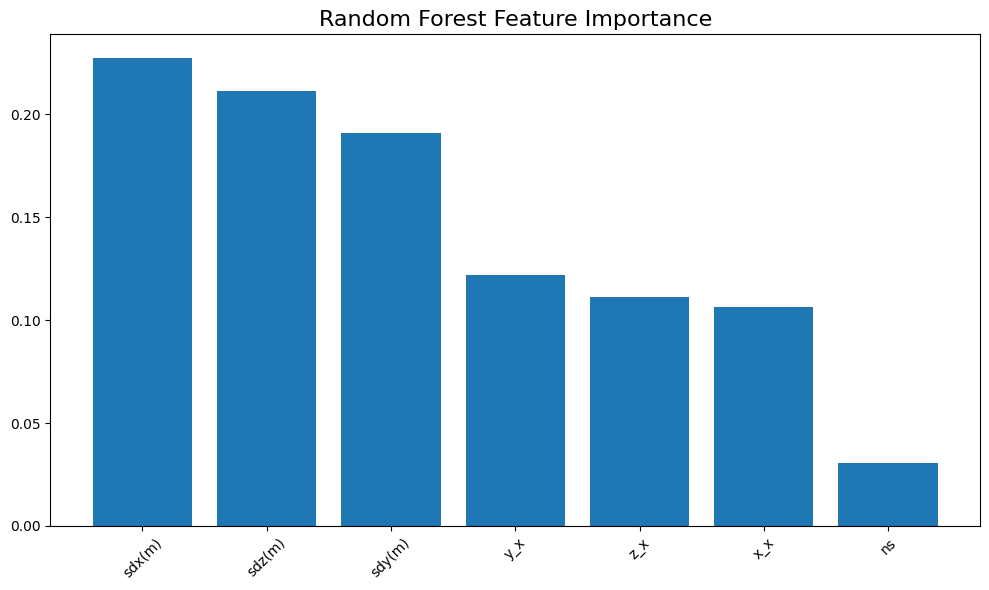


MODEL ACCURACY IMPROVEMENT ANALYSIS

--- 3D POSITION ERROR ---
Mean 3D Error (Original):  15.6230 m
Mean 3D Error (Corrected): 2.3959 m
Improvement: 13.2271 m (84.66%)

--- PER-AXIS MEAN ABSOLUTE ERROR ---
X-axis: 2.8363 → 0.8606 m  (Δ 1.9757 m)
Y-axis: 11.6085 → 1.7467 m  (Δ 9.8618 m)
Z-axis: 9.3412 → 0.9672 m  (Δ 8.3739 m)


In [38]:
feature_cols = ['x_x', 'y_x', 'z_x', 'ns', 'sdx(m)', 'sdy(m)', 'sdz(m)']
spp_x, spp_y, spp_z = 'x_x', 'y_x', 'z_x'
best_models, x_scaler, y_scaler, X_test, y_pred = train_ensemble_and_evaluate(X_train,X_test, y_train, y_test, feature_cols)
test_df = unified_df.loc[X_test.index]

calculate_accuracy_improvement(test_df, y_pred, (spp_x, spp_y, spp_z))